This notebook tests the semi-implicit evaporation/condensation solver implemented in `Rubble.update_solids`. The solver couples the dust surface density $\Sigma_d$ and vapor surface density $\Sigma_v$ via the Clausius-Clapeyron equilibrium pressure, and the tests here verify timestep convergence at three temperatures (1525 K, 1800 K, 1900 K) -- corresponding to regimes where the equilibrium vapor fraction is small, moderate, and dominant.

These tests correspond to Appendix A in [Li, Chen & Lin (2024)](https://ui.adsabs.harvard.edu/abs/2024MNRAS.529..893L).

In [1]:
import numpy as np
np.set_printoptions(edgeitems=5, linewidth=175, precision=5)
import matplotlib as mpl
import matplotlib.pyplot as plt
import pyridoxine.plt as rxplt
import astropy.constants as c
import astropy.units as u
import copy

import mpmath as mp
import torch
torch.set_printoptions(edgeitems=5, linewidth=175, precision=5)

from rubble import Rubble, RubbleData
dt_1d = 86400; dt_1yr = dt_1d * 365.25  # seconds per day / per year

In [2]:
# disk parameters for a grid of (alpha, u_f) at fixed stellar properties (B=1.8, R=1.8 Rsun)
# columns: B, R, Mdot, R_accu, H, H/R, T, Sigma_g, Sigma_d, a_critD
alpha = np.logspace(-3, -2, 5); u_f = np.logspace(2, 3, 5); npts = 5; Rs_sim = 1.8; Bs_sim = 1.0;
paras = np.array([
    [1.0, 1.8, 3.0567273878567306e-09, 0.09785230336148312,  46852902720.42457, 0.032006636472200395, 1880.6049173225863, 1451.6966181257487, 14.516966181257487, 0.014745135901271376],
    [1.0, 1.8, 3.0567273878567306e-09, 0.09785230336148312,  44231992398.78315, 0.030216213274910506,   1676.09089682269,  915.9586431634998,  9.159586431634999, 0.015618840131667084],
    [1.0, 1.8, 3.0567273878567306e-09, 0.09785230336148312, 41757693503.867516, 0.028525944782354356, 1493.8175841906534,  577.9308331441226,  5.779308331441227,   0.0165443145924169],
    [1.0, 1.8, 3.0567273878567306e-09, 0.09785230336148312,  39421804720.94017, 0.026930228428113313,  1331.366323310605,  364.6497037738412, 3.6464970377384125, 0.017524626862522586],
    [1.0, 1.8, 3.0567273878567306e-09, 0.09785230336148312, 37216583509.623344,  0.02542377504842475, 1186.5814846502524, 230.07840875863204, 2.3007840875863206,  0.01856302628646903]])

Bs, Rs, Mdot, R_accu, H, HoverR, T, Sigma_g, Sigma_d, a_critD = paras.T

In [3]:
# predicted equilibrium vapor surface density from Clausius-Clapeyron relation
# P_v_eq = P0 * 10^(-T_a/T), then Sigma_v_eq ~ P_v_eq * sqrt(2*pi) * H / c_s^2
pred_Sigma_v = 26 * 10**(8.203 - 25898.9/T) * u.bar.to(u.g/u.cm/u.s**2) * np.sqrt(2*np.pi) * H / ((c.k_B.cgs.value * T / (2.3 * c.m_p.cgs.value)) ** 0.5)**2
pred_Sigma_v

array([1.22170e+02, 2.70133e+00, 3.72523e-02, 3.02463e-04, 1.35538e-06])

In [4]:
# select which parameter combination to use from the (alpha, u_f, a_max_in) grid
supp_a_max = np.array([30, 100, 300, 1000])

ARRAY_INDEX = 34
a_idx = ARRAY_INDEX // 25
tmp_sub_idx = ARRAY_INDEX % 25
idx = tmp_sub_idx // 5; u_idx = tmp_sub_idx % 5;
a_in = supp_a_max[a_idx]
print(idx, u_idx, a_in, alpha[idx], u_f[u_idx])

1 4 100 0.0017782794100389228 1000.0


In [5]:
# helper to decode the flat ARRAY_INDEX into (alpha_idx, u_f_idx, a_max_in)
def get_all_idx(ARRAY_INDEX):
    a_idx = ARRAY_INDEX // 25
    tmp_sub_idx = ARRAY_INDEX % 25
    idx = tmp_sub_idx // 5; u_idx = tmp_sub_idx % 5;
    a_in = supp_a_max[a_idx]
    return idx, u_idx, a_in
get_all_idx(34)

(1, 4, np.int64(100))

# Numerical Tests on the Evaporation/Condensation Solver

Below we test timestep convergence of the semi-implicit evaporation/condensation solver at three temperatures. At each $T_0$, we run the solver with timesteps ranging from $\Delta t = 0.01$ s to $10^4$ s and verify that $\Sigma_v$ and $\Sigma_d$ converge to the expected equilibrium.

Corresponds to Appendix A in [Li, Chen & Lin (2024)](https://ui.adsabs.harvard.edu/abs/2024MNRAS.529..893L).

In [7]:
# timestep convergence test at T0 = 1800 K
# for each dt, initialize Rubble with dyn_env and latent_heat T-kappa model,
# then call update_solids repeatedly to evolve Sigma_v and Sigma_d
Sigma_vs, Sigma_ds, ts = [], [], []
dts = [0.01, 0.1, 1.0, 10, 100, 1000, 10000]
tlims = [1000, 1000, 3600, 3600, 86400, 86400, 86400]
for _i, dt in enumerate(dts):
    Sigma_v = np.zeros(int(tlims[_i]/dt) + 2); Sigma_d = np.zeros(int(tlims[_i]/dt) + 2); 
    time = np.linspace(0, (int(tlims[_i]/dt)+1) * dt, int(tlims[_i]/dt) + 2)
    
    ARRAY_INDEX=29; idx = 0; u_idx = 4; a_in = 100
    rt = Rubble(202, 1e-4, 1e4, 3.5, 100, coag2nearest=True,
                     ranged_dist=[1e-4, 1e-2],
                     Sigma_g = Sigma_g[idx], H = H[idx], T = 1800, alpha = alpha[idx], u_f=u_f[u_idx], rho_m=2.3,
                     Raccu = R_accu[idx], Z=0.05, Mdot = Mdot[idx], a_critD = a_critD[idx], a_max_in=a_in, 
                     dyn_env_burn_in = 0, delta_kappa_cap=0.01, T_kappa='latent_heat',
                     run_name = f"demo3_data/ArrIdx{ARRAY_INDEX}_{dt}")
    rt.full_St_flag = True
    rt.uni_gz_flag = True
    rt.dyn_env_flag = True
    rt.f_mod_flag = True
    rt.feedback_flag = True
    rt.mass_transfer_flag = False

    rt.rerr_th4dt = 1e-6
    rt.rerr_th = 1e-6
    rt.dyn_dt=1.0
    rt.tol_dyndt=2e-8
    
    Sigma_v[0], Sigma_d[0] = rt.Sigma_v, rt._Sigma_d
    print(dt)
    for idt in range(1, time.size):
        rt.update_solids(dt)
        Sigma_v[idt], Sigma_d[idt] = rt.Sigma_v, rt._Sigma_d
    Sigma_vs.append(Sigma_v); Sigma_ds.append(Sigma_d); ts.append(time)
    del rt

Selected torch device:  cuda ; default_dtype:  torch.float64
The initial kappa = 4.22e+01.
0.01
Selected torch device:  cuda ; default_dtype:  torch.float64
The initial kappa = 4.22e+01.
0.1
Selected torch device:  cuda ; default_dtype:  torch.float64
The initial kappa = 4.22e+01.
1.0
Selected torch device:  cuda ; default_dtype:  torch.float64
The initial kappa = 4.22e+01.
10
Selected torch device:  cuda ; default_dtype:  torch.float64
The initial kappa = 4.22e+01.
100
Selected torch device:  cuda ; default_dtype:  torch.float64
The initial kappa = 4.22e+01.
1000
Selected torch device:  cuda ; default_dtype:  torch.float64
The initial kappa = 4.22e+01.
10000


In [8]:
# save a deep copy of T=1800 K results before overwriting in the next test
Sigma_vs18, Sigma_ds18, ts18 = copy.deepcopy(Sigma_vs), copy.deepcopy(Sigma_ds), copy.deepcopy(ts)

Selected torch device:  cuda ; default_dtype:  torch.float64
The initial kappa = 4.22e+01.
Now we adjust dust surface density to make kappa unity.
Derived dotQ_plus[/Sigma_g] = 9.523e+02.


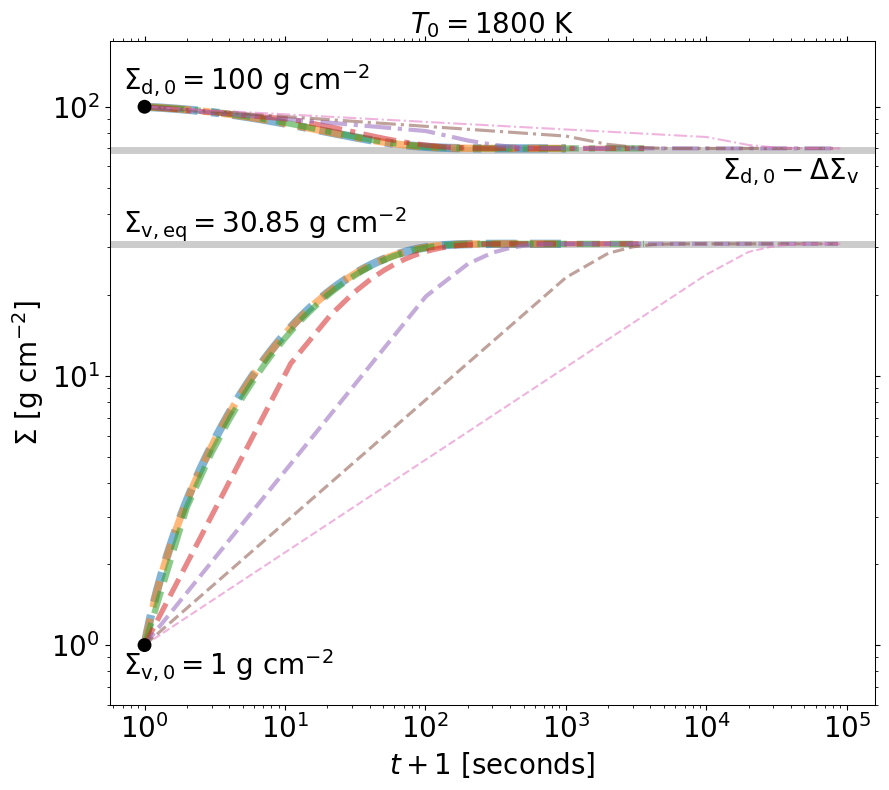

In [9]:
# plot Sigma_v (dashed) and Sigma_d (dot-dashed) vs time for each dt at T0=1800 K
# horizontal lines: predicted Sigma_v_eq and Sigma_d_0 - Delta Sigma_v
if True:
    rt = Rubble(202, 1e-4, 1e4, 3.5, 100, coag2nearest=True,
                     ranged_dist=[1e-4, 1e-2],
                     Sigma_g = Sigma_g[idx], H = H[idx], T = 1800, alpha = alpha[idx], u_f=u_f[u_idx], rho_m=2.3,
                     Raccu = R_accu[idx], Z=0.05, Mdot = Mdot[idx], a_critD = a_critD[idx], a_max_in=a_in, 
                     dyn_env_burn_in = 0, delta_kappa_cap=0.01, T_kappa='latent_heat',
                     run_name = f"demo3_data/ArrIdx{ARRAY_INDEX}_{dt}")
    rt.full_St_flag = True
    rt.uni_gz_flag = True
    rt.debug_flag = True
    rt.dyn_env_flag = True
    rt.f_mod_flag = True
    rt.feedback_flag = True
    rt.mass_transfer_flag = False

    rt.rerr_th4dt = 1e-6
    rt.rerr_th = 1e-6
    rt.dyn_dt=1.0
    rt.tol_dyndt=2e-8
    pred_Sigma_v = 26 * 10**(8.203 - 25898.9/rt.T) * u.bar.to(u.g/u.cm/u.s**2) * rt.sqrt_2_pi * rt.H / rt.c_s**2
    del rt
    
rxplt.plt_params('l'); fig, ax = plt.subplots(figsize=(9, 8))
for idt, dt in enumerate([0.01, 0.1, 1, 10, 100, 1000, 10000]):
    ax.loglog(ts18[idt]+1, Sigma_vs18[idt], '--', lw=6-idt*0.75, alpha=0.55, label=f"dt={dt:.0e} s")
    ax.loglog(ts18[idt]+1, Sigma_ds18[idt], '-.', lw=6-idt*0.75, alpha=0.55, color=ax.lines[-1].get_color())
ax.plot([], [], '--k', lw=3, alpha=0.55, label=r"$\Sigma_{\rm v}$")
ax.plot([], [], '-.k', lw=3, alpha=0.55, label=r"$\Sigma_{\rm d}$")
ax.axhline(pred_Sigma_v, c='k', ls='-', lw=5, alpha=0.2, zorder=-1)
ax.scatter([1, ], [100, ], marker='o', s=100, ec='None', fc='k', zorder=10)
ax.scatter([1, ], [1, ], marker='o', s=100, ec='None', fc='k', zorder=10)
ax.axhline(100-pred_Sigma_v, c='k', ls='-', lw=5, alpha=0.2, zorder=-1)
ax.text(0.7, pred_Sigma_v*1.1, r"$\Sigma_{\rm v,eq} = 30.85$ g cm$^{-2}$", fontsize=20)
ax.text(0.7, 100*1.15, r"$\Sigma_{\rm d,0} = 100$ g cm$^{-2}$", fontsize=20)
ax.text(0.7, 1*0.775, r"$\Sigma_{\rm v,0} = 1$ g cm$^{-2}$", fontsize=20)
ax.text(1.3e4, (100-pred_Sigma_v)*0.775, r"$\Sigma_{\rm d,0} - \Delta \Sigma_{\rm v}$", fontsize=20)

ax.set(xlabel=r"$t+1$ [seconds]", ylabel=r"$\Sigma$ [g cm$^{-2}$]", title=f"$T_0 = 1800$ K", ylim=[0.6, 175])

fig.tight_layout()

In [11]:
# timestep convergence test at T0 = 1900 K
# at this higher temperature, Sigma_v_eq > Sigma_d_0, so nearly all dust evaporates
Sigma_vs, Sigma_ds, ts = [], [], []
dts = [0.01, 0.1, 1.0, 10, 100, 1000, 10000]
tlims = [1000, 1000, 3600, 3600, 86400, 86400, 86400]
for _i, dt in enumerate(dts):
    Sigma_v = np.zeros(int(tlims[_i]/dt) + 2); Sigma_d = np.zeros(int(tlims[_i]/dt) + 2); 
    time = np.linspace(0, (int(tlims[_i]/dt)+1) * dt, int(tlims[_i]/dt) + 2)
    
    ARRAY_INDEX=29; idx = 0; u_idx = 4; a_in = 100
    rt = Rubble(202, 1e-4, 1e4, 3.5, 100, coag2nearest=True,
                     ranged_dist=[1e-4, 1e-2],
                     Sigma_g = Sigma_g[idx], H = H[idx], T = 1900, alpha = alpha[idx], u_f=u_f[u_idx], rho_m=2.3,
                     Raccu = R_accu[idx], Z=0.05, Mdot = Mdot[idx], a_critD = a_critD[idx], a_max_in=a_in, 
                     dyn_env_burn_in = 0, delta_kappa_cap=0.01, T_kappa='latent_heat',
                     run_name = f"demo3_data/ArrIdx{ARRAY_INDEX}_{dt}")
    rt.full_St_flag = True
    rt.uni_gz_flag = True
    rt.dyn_env_flag = True
    rt.f_mod_flag = True
    rt.feedback_flag = True
    rt.mass_transfer_flag = False

    rt.rerr_th4dt = 1e-6
    rt.rerr_th = 1e-6
    rt.dyn_dt=1.0
    rt.tol_dyndt=2e-8
    
    Sigma_v[0], Sigma_d[0] = rt.Sigma_v, rt._Sigma_d
    print(dt)
    for idt in range(1, time.size):
        rt.update_solids(dt)
        Sigma_v[idt], Sigma_d[idt] = rt.Sigma_v, rt._Sigma_d
    Sigma_vs.append(Sigma_v); Sigma_ds.append(Sigma_d); ts.append(time)
    del rt

Selected torch device:  cuda ; default_dtype:  torch.float64
The initial kappa = 4.27e+01.
0.01
Selected torch device:  cuda ; default_dtype:  torch.float64
The initial kappa = 4.27e+01.
0.1
Selected torch device:  cuda ; default_dtype:  torch.float64
The initial kappa = 4.27e+01.
1.0
Selected torch device:  cuda ; default_dtype:  torch.float64
The initial kappa = 4.27e+01.
10
Selected torch device:  cuda ; default_dtype:  torch.float64
The initial kappa = 4.27e+01.
100
Selected torch device:  cuda ; default_dtype:  torch.float64
The initial kappa = 4.27e+01.
1000
Selected torch device:  cuda ; default_dtype:  torch.float64
The initial kappa = 4.27e+01.
10000


In [12]:
Sigma_vs19, Sigma_ds19, ts19 = copy.deepcopy(Sigma_vs), copy.deepcopy(Sigma_ds), copy.deepcopy(ts)

In [13]:
# check the predicted Sigma_v_eq from the previous temperature (1800 K)
pred_Sigma_v

np.float64(30.852605059767555)

Selected torch device:  cuda ; default_dtype:  torch.float64
The initial kappa = 4.27e+01.
Now we adjust dust surface density to make kappa unity.
Derived dotQ_plus[/Sigma_g] = 1.005e+03.


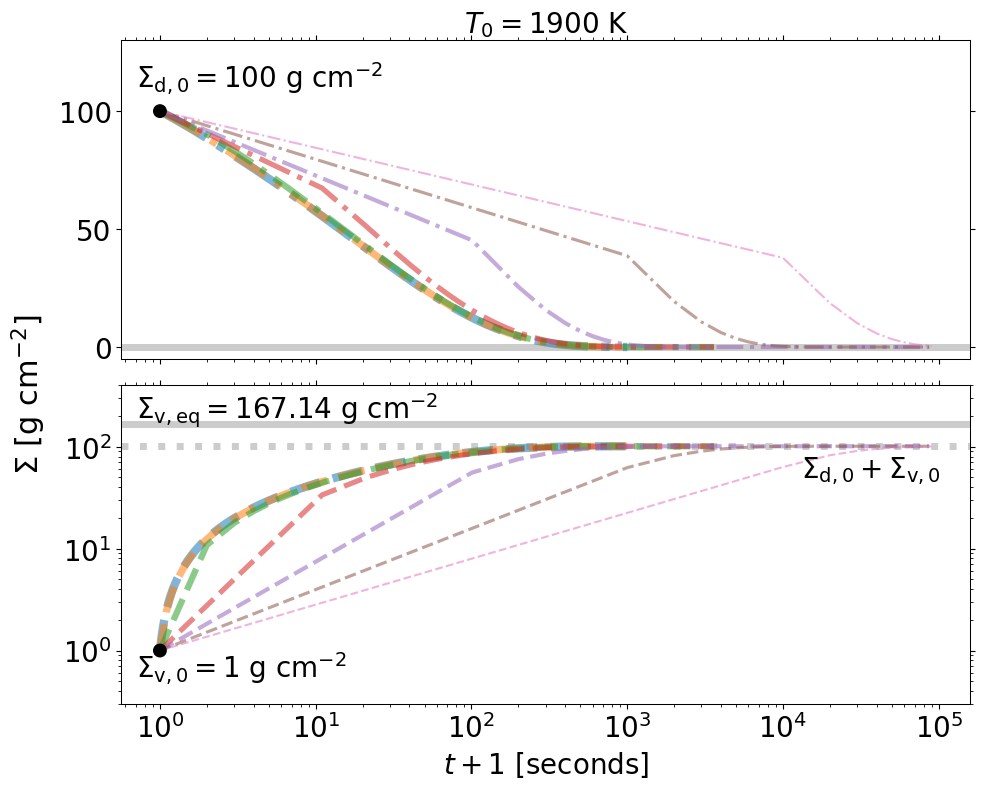

In [14]:
# plot Sigma_v (dashed) and Sigma_d (dot-dashed) vs time for each dt at T0=1900 K
# at 1900 K, Sigma_v_eq ~ 167 g/cm^2 > Sigma_d_0 = 100 g/cm^2,
# so dust is nearly fully evaporated and Sigma_d -> 0
if True:
    rt = Rubble(202, 1e-4, 1e4, 3.5, 100, coag2nearest=True,
                     ranged_dist=[1e-4, 1e-2],
                     Sigma_g = Sigma_g[idx], H = H[idx], T = 1900, alpha = alpha[idx], u_f=u_f[u_idx], rho_m=2.3,
                     Raccu = R_accu[idx], Z=0.05, Mdot = Mdot[idx], a_critD = a_critD[idx], a_max_in=a_in, 
                     dyn_env_burn_in = 0, delta_kappa_cap=0.01, T_kappa='latent_heat',
                     run_name = f"demo3_data/ArrIdx{ARRAY_INDEX}_{dt}")
    rt.full_St_flag = True
    rt.uni_gz_flag = True
    rt.debug_flag = True
    rt.dyn_env_flag = True
    rt.f_mod_flag = True
    rt.feedback_flag = True
    rt.mass_transfer_flag = False

    rt.rerr_th4dt = 1e-6
    rt.rerr_th = 1e-6
    rt.dyn_dt=1.0
    rt.tol_dyndt=2e-8
    pred_Sigma_v = 26 * 10**(8.203 - 25898.9/rt.T) * u.bar.to(u.g/u.cm/u.s**2) * rt.sqrt_2_pi * rt.H / rt.c_s**2
    del rt
    
rxplt.plt_params('l'); fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex='col')
for idt, dt in enumerate([0.01, 0.1, 1, 10, 100, 1000, 10000]):
    ax[1].loglog(ts19[idt]+1, Sigma_vs19[idt], '--', lw=6-idt*0.75, alpha=0.55, label=f"dt={dt:.0e} s")
    ax[0].semilogx(ts19[idt]+1, Sigma_ds19[idt], '-.', lw=6-idt*0.75, alpha=0.55, color=ax[1].lines[-1].get_color())
ax[1].axhline(pred_Sigma_v, c='k', ls='-', lw=5, alpha=0.2, zorder=-1)
ax[0].scatter([1, ], [100, ], marker='o', s=100, ec='None', fc='k', zorder=10)
ax[1].scatter([1, ], [1, ], marker='o', s=100, ec='None', fc='k', zorder=10)
ax[1].axhline(101, c='k', ls=':', lw=5, alpha=0.2, zorder=-1)
ax[0].axhline(0, c='k', ls='-', lw=5, alpha=0.2, zorder=-1)
ax[1].text(0.7, pred_Sigma_v*1.15, r"$\Sigma_{\rm v,eq} = 167.14$ g cm$^{-2}$", fontsize=20)
ax[0].text(0.7, 100*1.1, r"$\Sigma_{\rm d,0} = 100$ g cm$^{-2}$", fontsize=20)
ax[1].text(0.7, 1*0.55, r"$\Sigma_{\rm v,0} = 1$ g cm$^{-2}$", fontsize=20)
ax[1].text(1.3e4, 50, r"$\Sigma_{\rm d,0} + \Sigma_{\rm v,0}$", fontsize=20)

ax[1].set(xlabel=r"$t+1$ [seconds]", ylim=[0.3, 400])
ax[0].set(title=f"$T_0 = 1900$ K", ylim=[-5, 130])
fig.supylabel(r"$\Sigma$ [g cm$^{-2}$]", fontsize=22)

fig.tight_layout(); fig.subplots_adjust(wspace=0.01)

In [17]:
# timestep convergence test at T0 = 1525 K
# at this lower temperature, Sigma_v_eq ~ 0.09 g/cm^2 << Sigma_d_0,
# so very little evaporation occurs and Sigma_v converges to a small value
Sigma_vs, Sigma_ds, ts = [], [], []
dts = [0.01, 0.1, 1.0, 10, 100, 1000, 10000]
tlims = [1000, 1000, 3600, 3600, 86400, 86400, 86400]
for _i, dt in enumerate(dts):
    Sigma_v = np.zeros(int(tlims[_i]/dt) + 2); Sigma_d = np.zeros(int(tlims[_i]/dt) + 2); 
    time = np.linspace(0, (int(tlims[_i]/dt)+1) * dt, int(tlims[_i]/dt) + 2)
    
    ARRAY_INDEX=29; idx = 0; u_idx = 4; a_in = 100
    rt = Rubble(202, 1e-4, 1e4, 3.5, 100, coag2nearest=True,
                     ranged_dist=[1e-4, 1e-2],
                     Sigma_g = Sigma_g[idx], H = H[idx], T = 1525, alpha = alpha[idx], u_f=u_f[u_idx], rho_m=2.3,
                     Raccu = R_accu[idx], Z=0.05, Mdot = Mdot[idx], a_critD = a_critD[idx], a_max_in=a_in, 
                     dyn_env_burn_in = 0, delta_kappa_cap=0.01, T_kappa='latent_heat',
                     run_name = f"demo3_data/ArrIdx{ARRAY_INDEX}_{dt}")
    rt.full_St_flag = True
    rt.uni_gz_flag = True
    rt.dyn_env_flag = True
    rt.f_mod_flag = True
    rt.feedback_flag = True
    rt.mass_transfer_flag = False

    rt.rerr_th4dt = 1e-6
    rt.rerr_th = 1e-6
    rt.dyn_dt=1.0
    rt.tol_dyndt=2e-8
    
    Sigma_v[0], Sigma_d[0] = rt.Sigma_v, rt._Sigma_d
    print(dt)
    for idt in range(1, time.size):
        rt.update_solids(dt)
        Sigma_v[idt], Sigma_d[idt] = rt.Sigma_v, rt._Sigma_d
    Sigma_vs.append(Sigma_v); Sigma_ds.append(Sigma_d); ts.append(time)
    del rt

Selected torch device:  cuda ; default_dtype:  torch.float64
The initial kappa = 4.05e+01.
0.01
Selected torch device:  cuda ; default_dtype:  torch.float64
The initial kappa = 4.05e+01.
0.1
Selected torch device:  cuda ; default_dtype:  torch.float64
The initial kappa = 4.05e+01.
1.0
Selected torch device:  cuda ; default_dtype:  torch.float64
The initial kappa = 4.05e+01.
10
Selected torch device:  cuda ; default_dtype:  torch.float64
The initial kappa = 4.05e+01.
100
Selected torch device:  cuda ; default_dtype:  torch.float64
The initial kappa = 4.05e+01.
1000
Selected torch device:  cuda ; default_dtype:  torch.float64
The initial kappa = 4.05e+01.
10000


In [18]:
Sigma_vs15, Sigma_ds15, ts15 = copy.deepcopy(Sigma_vs), copy.deepcopy(Sigma_ds), copy.deepcopy(ts)

Selected torch device:  cuda ; default_dtype:  torch.float64
The initial kappa = 4.05e+01.
Now we adjust dust surface density to make kappa unity.
Derived dotQ_plus[/Sigma_g] = 8.068e+02.


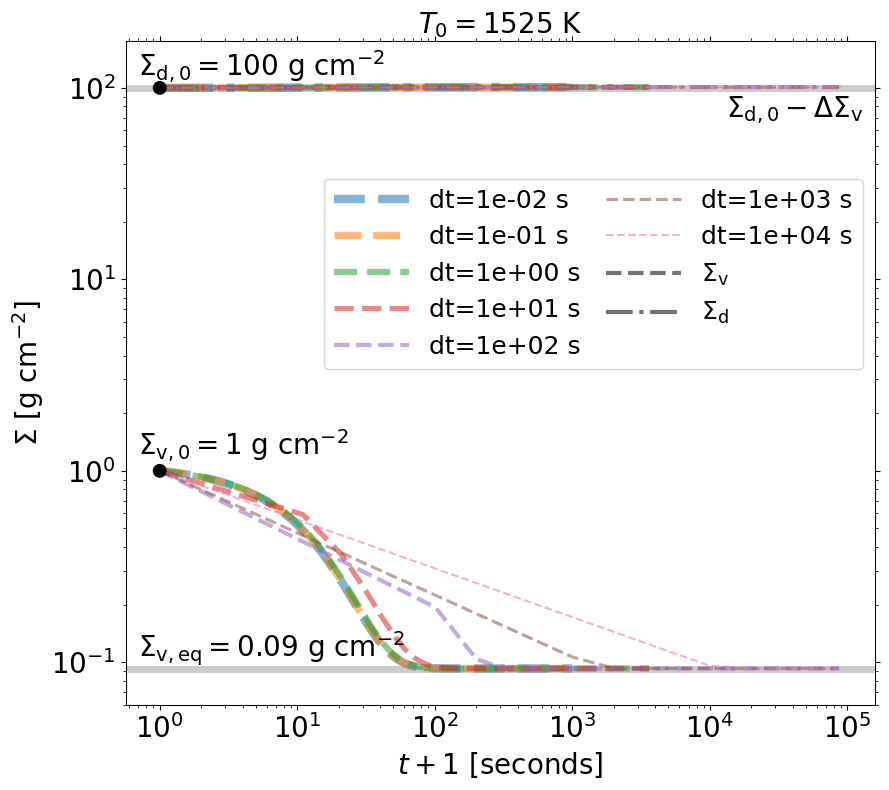

In [19]:
# plot Sigma_v and Sigma_d vs time for each dt at T0=1525 K
# at 1525 K, Sigma_v_eq ~ 0.09 g/cm^2, so dust barely evaporates
if True:
    rt = Rubble(202, 1e-4, 1e4, 3.5, 100, coag2nearest=True,
                     ranged_dist=[1e-4, 1e-2],
                     Sigma_g = Sigma_g[idx], H = H[idx], T = 1525, alpha = alpha[idx], u_f=u_f[u_idx], rho_m=2.3,
                     Raccu = R_accu[idx], Z=0.05, Mdot = Mdot[idx], a_critD = a_critD[idx], a_max_in=a_in, 
                     dyn_env_burn_in = 0, delta_kappa_cap=0.01, T_kappa='latent_heat',
                     run_name = f"demo3_data/ArrIdx{ARRAY_INDEX}_{dt}")
    rt.full_St_flag = True
    rt.uni_gz_flag = True
    rt.debug_flag = True
    rt.dyn_env_flag = True
    rt.f_mod_flag = True
    rt.feedback_flag = True
    rt.mass_transfer_flag = False

    rt.rerr_th4dt = 1e-6
    rt.rerr_th = 1e-6
    rt.dyn_dt=1.0
    rt.tol_dyndt=2e-8
    pred_Sigma_v = 26 * 10**(8.203 - 25898.9/rt.T) * u.bar.to(u.g/u.cm/u.s**2) * rt.sqrt_2_pi * rt.H / rt.c_s**2
    del rt
    
rxplt.plt_params('l'); fig, ax = plt.subplots(figsize=(9, 8))
for idt, dt in enumerate([0.01, 0.1, 1, 10, 100, 1000, 10000]):
    ax.loglog(ts15[idt]+1, Sigma_vs15[idt], '--', lw=6-idt*0.75, alpha=0.55, label=f"dt={dt:.0e} s")
    ax.loglog(ts15[idt]+1, Sigma_ds15[idt], '-.', lw=6-idt*0.75, alpha=0.55, color=ax.lines[-1].get_color())
ax.plot([], [], '--k', lw=3, alpha=0.55, label=r"$\Sigma_{\rm v}$")
ax.plot([], [], '-.k', lw=3, alpha=0.55, label=r"$\Sigma_{\rm d}$")
ax.axhline(pred_Sigma_v, c='k', ls='-', lw=5, alpha=0.2, zorder=-1)
ax.scatter([1, ], [100, ], marker='o', s=100, ec='None', fc='k', zorder=10)
ax.scatter([1, ], [1, ], marker='o', s=100, ec='None', fc='k', zorder=10)
ax.axhline(100-pred_Sigma_v, c='k', ls='-', lw=5, alpha=0.2, zorder=-1)
ax.text(0.7, pred_Sigma_v*1.15, r"$\Sigma_{\rm v,eq} = 0.09$ g cm$^{-2}$", fontsize=20)
ax.text(0.7, 100*1.15, r"$\Sigma_{\rm d,0} = 100$ g cm$^{-2}$", fontsize=20)
ax.text(0.7, 1*1.2, r"$\Sigma_{\rm v,0} = 1$ g cm$^{-2}$", fontsize=20)
ax.text(1.3e4, (100-pred_Sigma_v)*0.7, r"$\Sigma_{\rm d,0} - \Delta \Sigma_{\rm v}$", fontsize=20)

ax.set(xlabel=r"$t+1$ [seconds]", ylabel=r"$\Sigma$ [g cm$^{-2}$]", title=f"$T_0 = 1525$ K", ylim=[0.06, 175])
ax.legend(loc='center right', handlelength=3, ncol=2, fontsize=18, columnspacing=1, bbox_to_anchor=(1, 0.65)); 

fig.tight_layout()